# 06 — Evaluation Metrics & Final Results
Confusion matrix, F1, IoU, ROC curves, precision/recall, predicted LULC map, summary.

**Requires:** Run notebooks 01–05 first.

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, precision_score, recall_score,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(PROJECT_ROOT, 'data', 'config.json')) as f:
    cfg = json.load(f)
FIG_DIR = cfg['paths']['fig_dir']
PROCESSED_DIR = cfg['paths']['processed_dir']
os.makedirs(FIG_DIR, exist_ok=True)

# Load test predictions
tp = np.load(os.path.join(PROCESSED_DIR, 'test_predictions.npz'), allow_pickle=True)
all_preds = tp['preds']
all_labels = tp['labels']
all_probs = tp['probs']
class_names = list(tp['class_names'])
idx_to_class = json.loads(str(tp['idx_to_class']))
num_classes = len(class_names)

# Load features/labels and predicted map
data = np.load(os.path.join(PROCESSED_DIR, 'features_labels.npz'))
features = data['features']
labels_raw = data['labels']

pm = np.load(os.path.join(PROCESSED_DIR, 'predicted_lulc_map.npz'))
predicted_lulc = pm['predicted_lulc']

LULC_CLASSES = {
    1: ('Water', '#1A5BAB'), 2: ('Trees', '#358221'), 4: ('Flooded Vegetation', '#87D19E'),
    5: ('Crops', '#FFDB5C'), 7: ('Built Area', '#ED022A'), 8: ('Bare Ground', '#EDE9E4'),
    9: ('Snow/Ice', '#F2FAFF'), 10: ('Clouds', '#C8C8C8'), 11: ('Rangeland', '#C6AD8D'),
}
vals = sorted(LULC_CLASSES.keys())
lulc_cmap = ListedColormap([LULC_CLASSES[v][1] for v in vals])
lulc_norm = BoundaryNorm(vals + [max(vals)+1], lulc_cmap.N)

print(f'Test samples: {len(all_preds)} | Classes: {num_classes}')

Test samples: 11511 | Classes: 6


## 6.1 Confusion Matrix

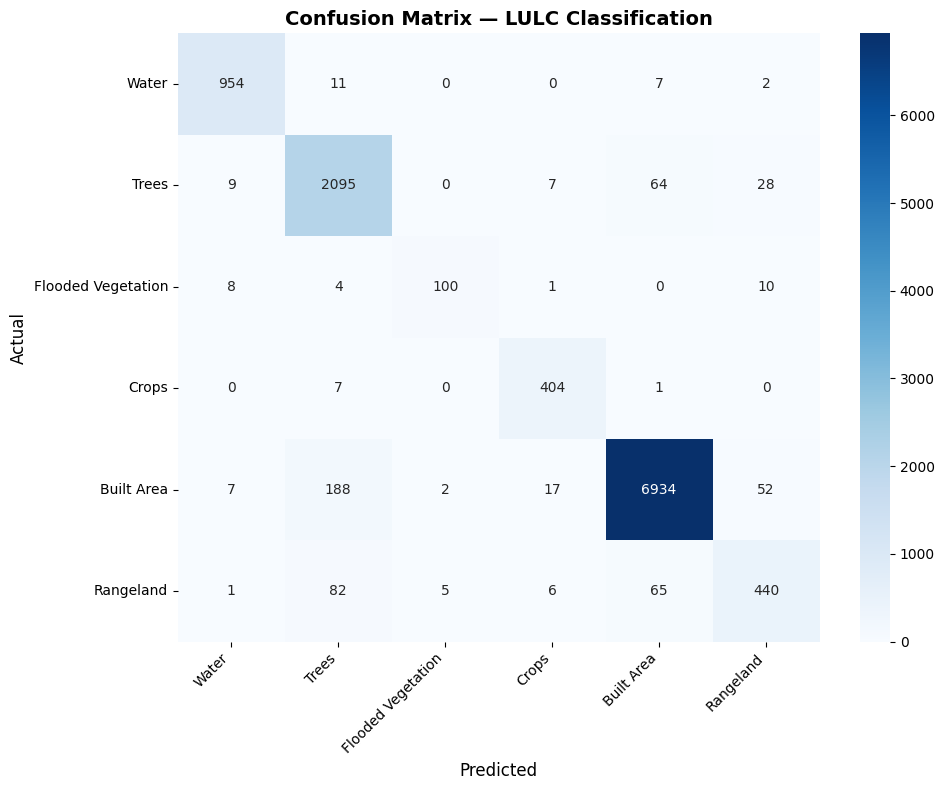

Saved: /content/lulc_notebook_project/outputs/figures/06_confusion_matrix.png


In [3]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix — LULC Classification', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_confusion_matrix.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 6.2 Normalized Confusion Matrix

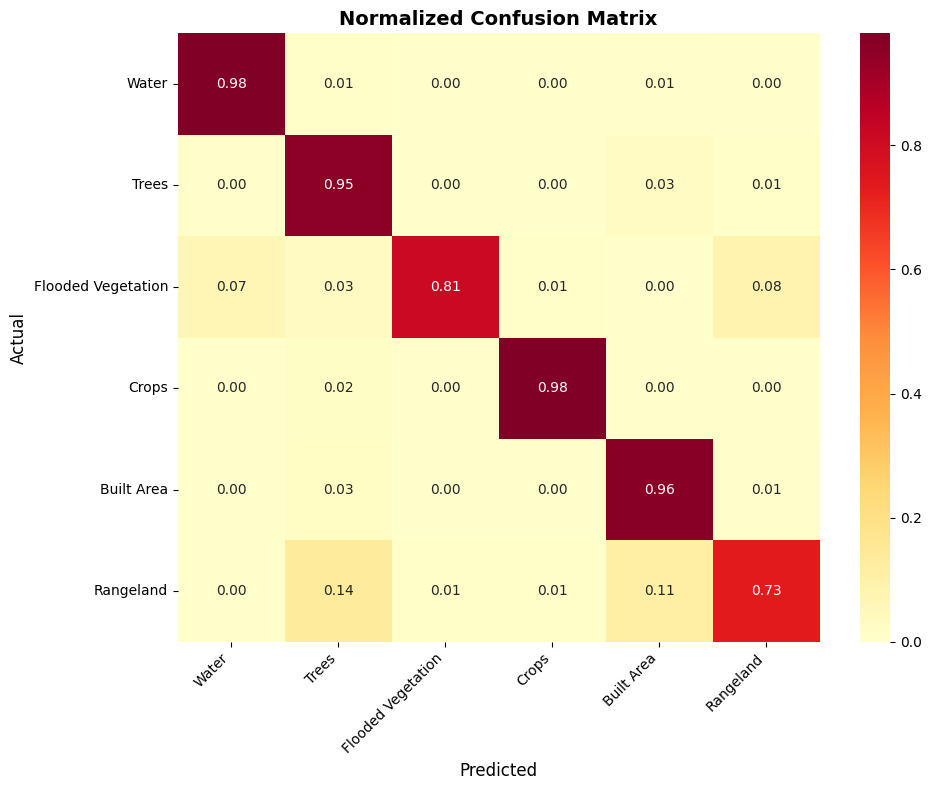

Saved: /content/lulc_notebook_project/outputs/figures/06_confusion_matrix_normalized.png


In [4]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_confusion_matrix_normalized.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 6.3 Classification Report

In [5]:
print('=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

             Water     0.9745    0.9795    0.9770       974
             Trees     0.8777    0.9510    0.9129      2203
Flooded Vegetation     0.9346    0.8130    0.8696       123
             Crops     0.9287    0.9806    0.9540       412
        Built Area     0.9806    0.9631    0.9718      7200
         Rangeland     0.8271    0.7346    0.7781       599

          accuracy                         0.9493     11511
         macro avg     0.9205    0.9036    0.9105     11511
      weighted avg     0.9501    0.9493    0.9491     11511



## 6.4 Per-Class Precision, Recall, F1 Bar Charts

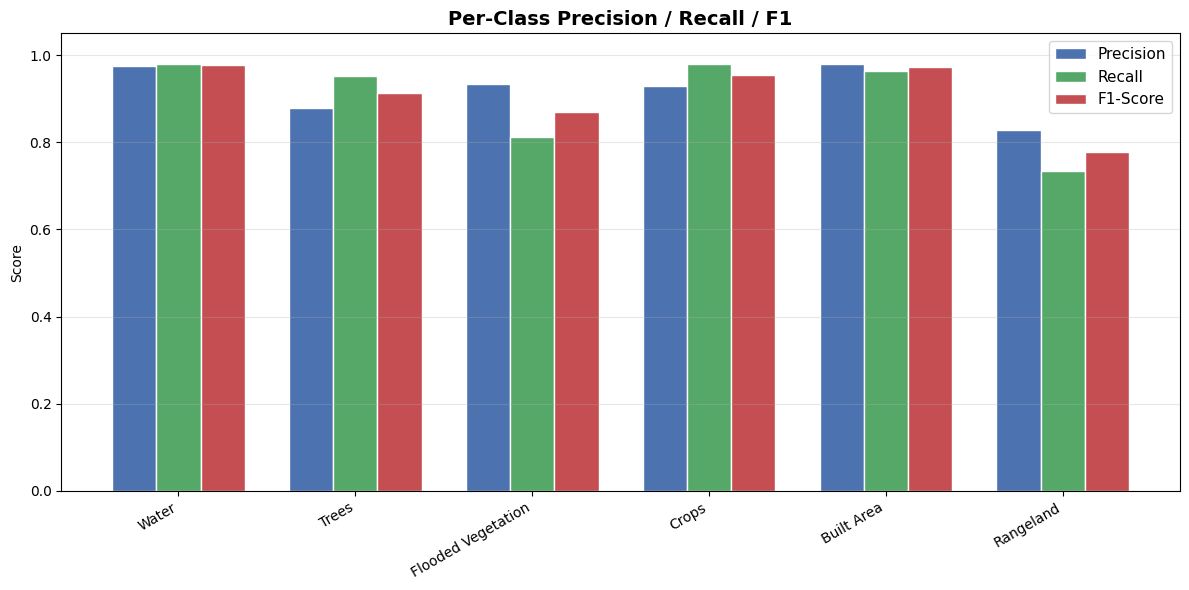

Saved: /content/lulc_notebook_project/outputs/figures/06_precision_recall_f1.png


In [6]:
prec = precision_score(all_labels, all_preds, average=None, zero_division=0)
rec  = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1   = f1_score(all_labels, all_preds, average=None, zero_division=0)

x = np.arange(num_classes)
w = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w, prec, w, label='Precision', color='#4C72B0', edgecolor='white')
ax.bar(x,     rec,  w, label='Recall',    color='#55A868', edgecolor='white')
ax.bar(x + w, f1,   w, label='F1-Score',  color='#C44E52', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class Precision / Recall / F1', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_precision_recall_f1.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 6.5 F1 & IoU Grouped Bar Chart

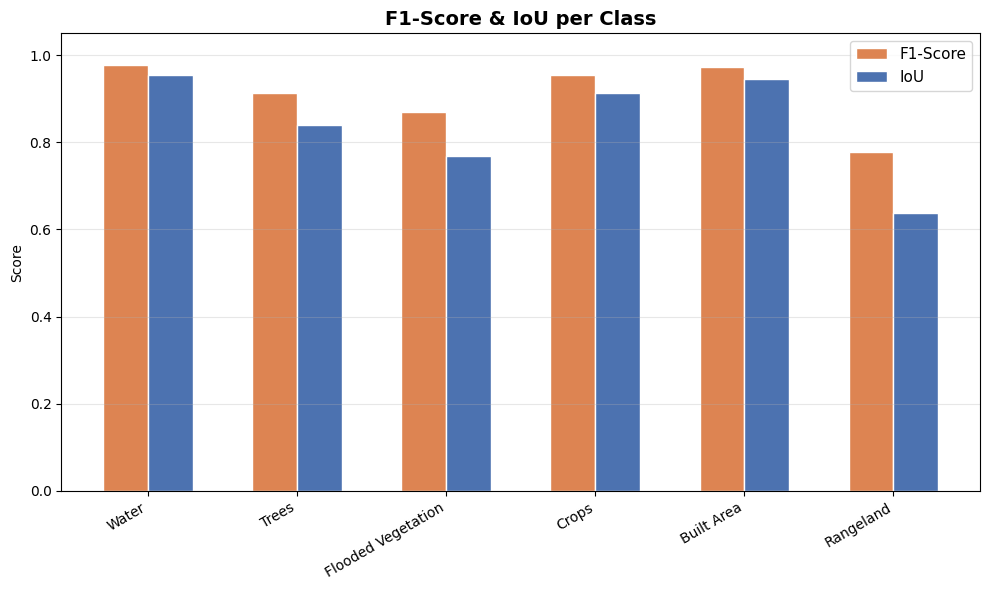

Saved: /content/lulc_notebook_project/outputs/figures/06_f1_iou_barplot.png

F1 & IoU per class:
  Water                      F1=0.9770  IoU=0.9550
  Trees                      F1=0.9129  IoU=0.8397
  Flooded Vegetation         F1=0.8696  IoU=0.7692
  Crops                      F1=0.9540  IoU=0.9120
  Built Area                 F1=0.9718  IoU=0.9451
  Rangeland                  F1=0.7781  IoU=0.6368

  Macro F1:    0.9105
  Weighted F1: 0.9491
  Mean IoU:    0.8429


In [7]:
def compute_iou(cm):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    return inter / (union + 1e-10)

iou = compute_iou(cm)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 0.15, f1, 0.3, label='F1-Score', color='#DD8452', edgecolor='white')
ax.bar(x + 0.15, iou, 0.3, label='IoU', color='#4C72B0', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('F1-Score & IoU per Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_f1_iou_barplot.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

# Print values
print('\nF1 & IoU per class:')
for i, n in enumerate(class_names):
    print(f'  {n:25s}  F1={f1[i]:.4f}  IoU={iou[i]:.4f}')
print(f'\n  Macro F1:    {f1_score(all_labels, all_preds, average="macro"):.4f}')
print(f'  Weighted F1: {f1_score(all_labels, all_preds, average="weighted"):.4f}')
print(f'  Mean IoU:    {np.mean(iou):.4f}')

## 6.6 ROC Curves (One-vs-Rest)

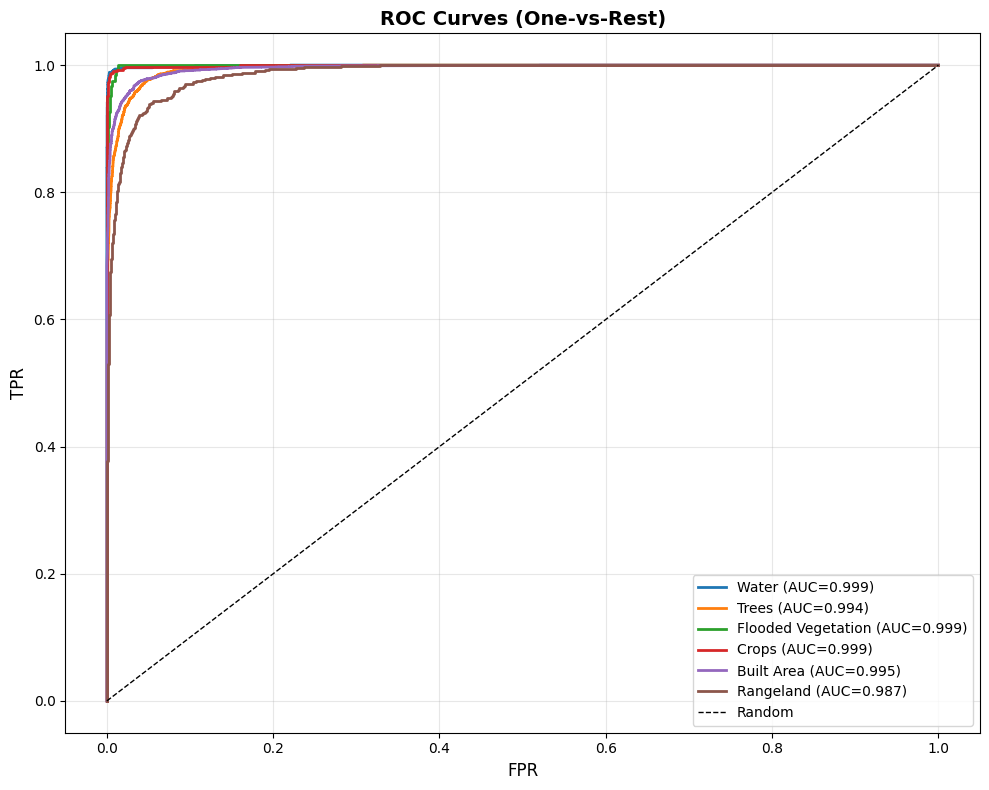

Saved: /content/lulc_notebook_project/outputs/figures/06_roc_curves.png


In [8]:
labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(num_classes):
    if labels_bin[:, i].sum() > 0:
        fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC={roc_auc_val:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=12); ax.set_ylabel('TPR', fontsize=12)
ax.set_title('ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_roc_curves.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 6.7 Predicted LULC Map vs Ground Truth

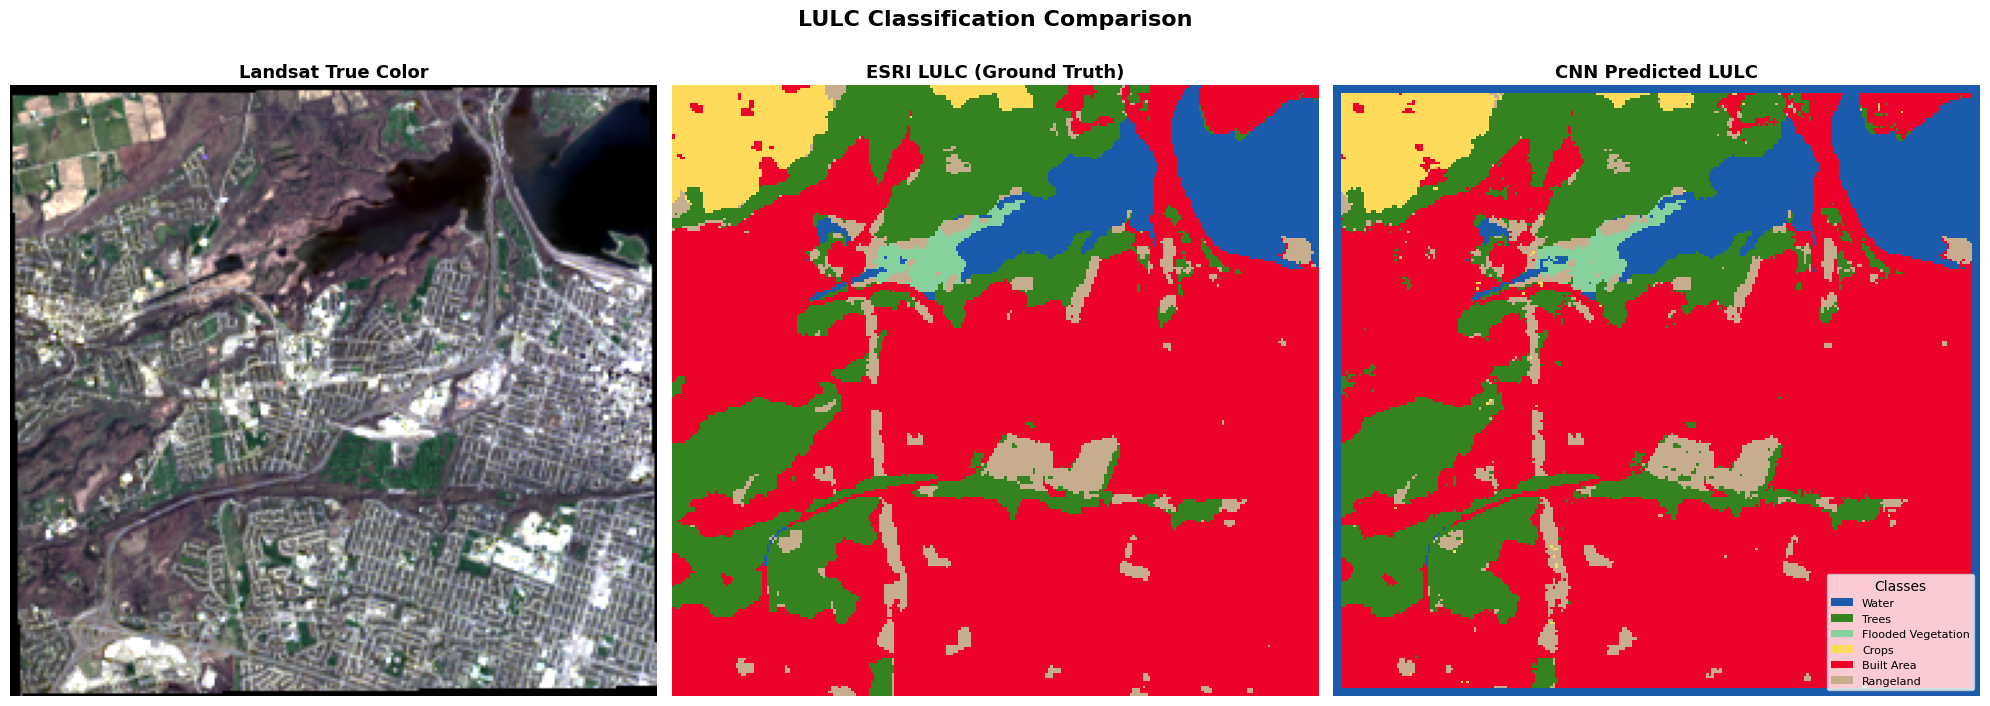

Saved: /content/lulc_notebook_project/outputs/figures/06_prediction_comparison.png


In [9]:
def pnorm(x):
    v = x[x > 0]
    if len(v) == 0: return x
    lo, hi = np.percentile(v, [2, 98])
    return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)

rgb = np.dstack([pnorm(features[2]), pnorm(features[1]), pnorm(features[0])])

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(rgb); axes[0].set_title('Landsat True Color', fontsize=13, fontweight='bold'); axes[0].axis('off')
axes[1].imshow(labels_raw, cmap=lulc_cmap, norm=lulc_norm, interpolation='nearest')
axes[1].set_title('ESRI LULC (Ground Truth)', fontsize=13, fontweight='bold'); axes[1].axis('off')
axes[2].imshow(predicted_lulc, cmap=lulc_cmap, norm=lulc_norm, interpolation='nearest')
axes[2].set_title('CNN Predicted LULC', fontsize=13, fontweight='bold'); axes[2].axis('off')

present = [v for v in vals if v in np.unique(predicted_lulc)]
legend_patches = [Patch(facecolor=LULC_CLASSES[v][1], label=LULC_CLASSES[v][0]) for v in present]
axes[2].legend(handles=legend_patches, loc='lower right', fontsize=8, title='Classes')

plt.suptitle('LULC Classification Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_prediction_comparison.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 6.8 Difference Map (Agreement / Disagreement)

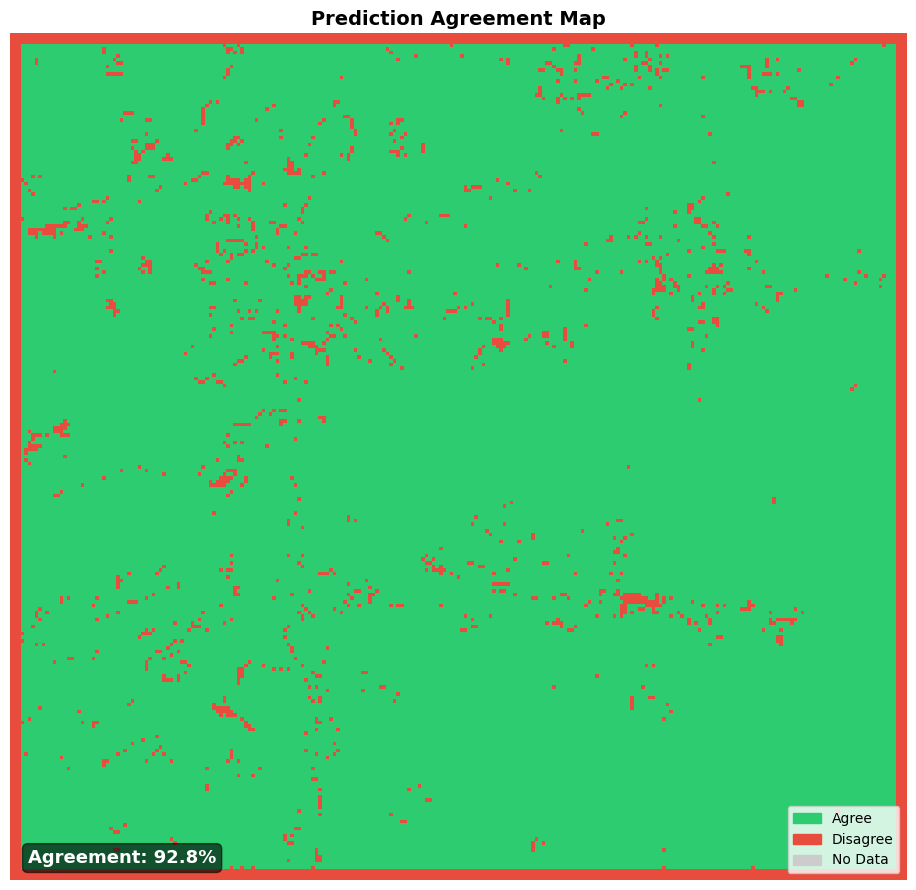

Saved: /content/lulc_notebook_project/outputs/figures/06_agreement_map.png


In [10]:
agree = (predicted_lulc == labels_raw).astype(np.uint8)
agree[labels_raw <= 0] = 2  # nodata

fig, ax = plt.subplots(figsize=(10, 9))
diff_cmap = ListedColormap(['#E74C3C', '#2ECC71', '#CCCCCC'])
ax.imshow(agree, cmap=diff_cmap, vmin=0, vmax=2, interpolation='nearest')
ax.set_title('Prediction Agreement Map', fontsize=14, fontweight='bold')
ax.axis('off')
patches = [Patch(color='#2ECC71', label='Agree'),
           Patch(color='#E74C3C', label='Disagree'),
           Patch(color='#CCCCCC', label='No Data')]
ax.legend(handles=patches, loc='lower right', fontsize=10)
valid = agree[labels_raw > 0]
agree_pct = 100 * (valid == 1).sum() / len(valid)
ax.text(0.02, 0.02, f'Agreement: {agree_pct:.1f}%', transform=ax.transAxes,
        fontsize=13, fontweight='bold', color='white',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.6))
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '06_agreement_map.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 6.9 Final Summary

In [11]:
overall_acc = (all_preds == all_labels).mean()
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
mean_iou = np.mean(iou)

print('=' * 55)
print('        FINAL ACCURACY SUMMARY')
print('=' * 55)
print(f'  Overall Accuracy  : {overall_acc:.4f}')
print(f'  Macro F1 Score    : {macro_f1:.4f}')
print(f'  Weighted F1 Score : {weighted_f1:.4f}')
print(f'  Mean IoU          : {mean_iou:.4f}')
print('=' * 55)

        FINAL ACCURACY SUMMARY
  Overall Accuracy  : 0.9493
  Macro F1 Score    : 0.9105
  Weighted F1 Score : 0.9491
  Mean IoU          : 0.8429
